# Language Detection EDA

This notebook explores the CantoNLU language-detection dataset for Milestone 2.

The goals are to verify:
- dataset sizes, columns and labels
- class balance across splits
- how examples are grouped by `source_id`
- duplicate examples and sentences that appear with conflicting labels
- overlap between train, validation, and test (by sentence and by `source_id`)
- text-length distributions per class
- sample examples

## Data source and labels

The data comes from the CantoNLU repository (https://github.com/Aatlantise/canto-nlu), folder `data/ld/`.
It is kept locally in `data/ld/` and is not committed to this repository.

Each row has four fields:
- `id` — row number within the file
- `source_id` — the original sentence the row was generated from; rows with the same `source_id` are versions of the same sentence
- `sentence` — the text
- `label` — the class

Label meanings, as documented in `canto-nlu/data/ld/README.md`:
- `0`: original Cantonese sentence
- `1`: original Mandarin sentence (converted to traditional characters)
- `2`: corrupted, partially code-mixed sentence

These definitions come from the upstream README; they have not yet been checked against the upstream generation code.

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from difflib import SequenceMatcher

In [2]:
DATA_DIR = Path("../data/ld")

train = pd.read_json(DATA_DIR / "ld_train.jsonl", lines=True)
valid = pd.read_json(DATA_DIR / "ld_val.jsonl", lines=True)
test = pd.read_json(DATA_DIR / "ld_test.jsonl", lines=True)

# Label ids in the raw files -> readable names (meanings from the upstream README)
LABEL_NAMES = {0: "Cantonese", 1: "Mandarin", 2: "Code-mixed"}

splits = {"train": train, "valid": valid, "test": test}
for df in splits.values():
    df["label_name"] = df["label"].map(LABEL_NAMES)

## Dataset sizes and columns

In [3]:
print("Train shape: {}".format(train.shape))
print("Train dtypes: {}".format(train.dtypes))
train.head()

Train shape: (42753, 5)
Train dtypes: id             int64
source_id      int64
sentence      object
label          int64
label_name    object
dtype: object


,id,source_id,sentence,label,label_name
0,0,0,建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣咗，其餘嘅係租住單位。,2,Code-mixed
1,1,0,建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣瞭，其餘的係租住單位。,2,Code-mixed
2,2,0,建生邨屬於租者置其屋計劃嘅屋邨，同一大廈內，有啲單位已經賣咗，其餘的係租住單位。,2,Code-mixed
3,3,0,建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有啲單位已經賣瞭，其餘的是租住單位。,2,Code-mixed
4,4,0,建生邨屬於租者置其屋計劃嘅屋邨，同一大廈內，有啲單位已經賣咗，其餘嘅係租住單位。,0,Cantonese


In [4]:
print("Valid shape: {}".format(valid.shape))
print("Valid dtypes: {}".format(valid.dtypes))
valid.head()

Valid shape: (2425, 5)
Valid dtypes: id             int64
source_id      int64
sentence      object
label          int64
label_name    object
dtype: object


,id,source_id,sentence,label,label_name
0,0,9003,日本足球代錶隊球員古前田充是日本足球運動員，司職前鋒，曾在1976～1977年間爲日本足球代...,2,Code-mixed
1,1,9003,日本足球代表隊球員古前田充係日本足球員，司職前鋒，曾動喺1976～1977年間爲日本足球代表...,2,Code-mixed
2,2,9003,日本足球代錶隊球員古前田充是日本足球運動員，司職前鋒，曾在1976～1977年間爲日本足球代...,2,Code-mixed
3,3,9003,日本足球代表隊球員古前田充係日本足球員，司職前鋒，曾經喺1976～1977年間爲日本足球代表...,2,Code-mixed
4,4,9003,日本足球代錶隊球員古前田充係日本足球運動員，司職前鋒，曾在1976～1977年間為日本足球代...,2,Code-mixed


In [5]:
# The test split is locked: we only check its size and format, not its examples.
print("Test shape: {}".format(test.shape))
print("Test dtypes: {}".format(test.dtypes))

Test shape: (2341, 5)
Test dtypes: id             int64
source_id      int64
sentence      object
label          int64
label_name    object
dtype: object


In [6]:
# Check for missing values and empty sentences in every split
for split_name, df in splits.items():
    print(f"Missing values in {split_name} split:")
    print(df.isnull().sum())
    print(f"Empty or whitespace-only sentences in {split_name}:", (df["sentence"].str.strip() == "").sum())
    print()

Missing values in train split:
id            0
source_id     0
sentence      0
label         0
label_name    0
dtype: int64
Empty or whitespace-only sentences in train: 0

Missing values in valid split:
id            0
source_id     0
sentence      0
label         0
label_name    0
dtype: int64
Empty or whitespace-only sentences in valid: 0

Missing values in test split:
id            0
source_id     0
sentence      0
label         0
label_name    0
dtype: int64
Empty or whitespace-only sentences in test: 0



- No missing values or empty sentences were found in any split.
- Only `sentence` (input) and `label` (target) will be used by the models. `source_id` is kept because it identifies the group split and will be useful for error analysis; `id` is a row number with no information. No columns are removed here: cleaning decisions are made in the modelling pipeline (M3), not in the EDA.
- The raw files have 4 columns; `label_name` (the readable label) is added by this notebook, which is why the shapes above show 5.

## Class distribution

In [7]:
# count how many examples each label has in each split
for split_name, df in splits.items():
    print(f"{split_name} label counts:")
    print(df["label"].value_counts().sort_index())
    print(df["label"].value_counts(normalize=True).sort_index().round(3))
    print()

train label counts:
label
0     6924
1     6971
2    28858
Name: count, dtype: int64
label
0    0.162
1    0.163
2    0.675
Name: proportion, dtype: float64

valid label counts:
label
0     398
1     399
2    1628
Name: count, dtype: int64
label
0    0.164
1    0.165
2    0.671
Name: proportion, dtype: float64

test label counts:
label
0     396
1     398
2    1547
Name: count, dtype: int64
label
0    0.169
1    0.170
2    0.661
Name: proportion, dtype: float64



## How rows are grouped by `source_id`

Each original sentence (`source_id`) produced several rows. We look at one group, then at group sizes.

In [8]:
first_id = train["source_id"].iloc[0]
train[train["source_id"] == first_id]

,id,source_id,sentence,label,label_name
0,0,0,建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣咗，其餘嘅係租住單位。,2,Code-mixed
1,1,0,建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣瞭，其餘的係租住單位。,2,Code-mixed
2,2,0,建生邨屬於租者置其屋計劃嘅屋邨，同一大廈內，有啲單位已經賣咗，其餘的係租住單位。,2,Code-mixed
3,3,0,建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有啲單位已經賣瞭，其餘的是租住單位。,2,Code-mixed
4,4,0,建生邨屬於租者置其屋計劃嘅屋邨，同一大廈內，有啲單位已經賣咗，其餘嘅係租住單位。,0,Cantonese
5,5,0,建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣瞭，其餘的是租住單位。,1,Mandarin


In [9]:
# how many source sentences produced 1, 2, ..., 8 rows
rows_per_source = train.groupby("source_id").size()
rows_per_source.value_counts().sort_index()

1      87
2     818
3    1263
4     874
5    1254
6    1201
7    1323
8    1376
Name: count, dtype: int64

- Groups are **not a fixed size**: a source sentence produced between 1 and 8 rows in the training set.
- 87 source sentences have only a single row, so not every source sentence has a Cantonese, a Mandarin, and a code-mixed version.

In [10]:
# print label, length and text of each row in the first group
group = train[train["source_id"] == first_id]

for _, row in group.iterrows():
    print(row["label"], len(row["sentence"]), row["sentence"])

2 40 建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣咗，其餘嘅係租住單位。
2 40 建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣瞭，其餘的係租住單位。
2 40 建生邨屬於租者置其屋計劃嘅屋邨，同一大廈內，有啲單位已經賣咗，其餘的係租住單位。
2 40 建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有啲單位已經賣瞭，其餘的是租住單位。
0 40 建生邨屬於租者置其屋計劃嘅屋邨，同一大廈內，有啲單位已經賣咗，其餘嘅係租住單位。
1 40 建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣瞭，其餘的是租住單位。


In [11]:
# character-level similarity between every pair of sentences in the group
# (1.00 = identical, 0.00 = nothing in common; no knowledge of the language needed)
sentences = group["sentence"].tolist()
labels = group["label"].tolist()

for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        similarity = SequenceMatcher(None, sentences[i], sentences[j]).ratio()
        print(f"label {labels[i]} vs label {labels[j]}: similarity = {similarity:.2f}")

label 2 vs label 2: similarity = 0.95
label 2 vs label 2: similarity = 0.93
label 2 vs label 2: similarity = 0.90
label 2 vs label 0: similarity = 0.95
label 2 vs label 1: similarity = 0.93
label 2 vs label 2: similarity = 0.93
label 2 vs label 2: similarity = 0.95
label 2 vs label 0: similarity = 0.90
label 2 vs label 1: similarity = 0.97
label 2 vs label 2: similarity = 0.93
label 2 vs label 0: similarity = 0.97
label 2 vs label 1: similarity = 0.90
label 2 vs label 0: similarity = 0.90
label 2 vs label 1: similarity = 0.97
label 0 vs label 1: similarity = 0.88


- All rows in the group have the same length (40 characters) and are very similar at the character level: every pair has a similarity between 0.88 and 0.97.
- Even the Cantonese (label 0) and Mandarin (label 1) versions are 0.88 similar. They differ only in a few characters, so the task depends on **small character-level differences**, not on whole sentences being different.
- The code-mixed rows (label 2) look like mixtures of the Cantonese and Mandarin versions: each one is very close (0.90–0.97) to both.
- The Mandarin sentence contains `賣瞭`, and a validation example contains `代錶隊`, where standard traditional Chinese would be `賣了` and `代表隊`. These look like errors from automatic simplified-to-traditional conversion (one simplified character can map to several traditional ones). This is a hypothesis to verify against the upstream conversion code.
- This is one group only; these observations need to be checked on the whole dataset.

## Duplicate sentences

In [12]:
for split_name, df in splits.items():
    print(split_name, "duplicate sentences:", df["sentence"].duplicated().sum())

train duplicate sentences: 268
valid duplicate sentences: 23
test duplicate sentences: 14


In [13]:
# show all copies of each duplicated sentence next to each other
dups = train[train["sentence"].duplicated(keep=False)]
dups.sort_values("sentence").head(10)

,id,source_id,sentence,label,label_name
39299,39299,8279,1160年2月18日，日本永曆元年，二條天皇平治改元永曆。,2,Code-mixed
39301,39301,8279,1160年2月18日，日本永曆元年，二條天皇平治改元永曆。,1,Mandarin
34640,34640,7253,1314年開始用用延祐」年號。,2,Code-mixed
34641,34641,7253,1314年開始用用延祐」年號。,2,Code-mixed
5283,5283,1088,1334年3月5號，日本建武元年-元弘改元做建武。,2,Code-mixed
5280,5280,1088,1334年3月5號，日本建武元年-元弘改元做建武。,2,Code-mixed
28342,28342,5917,1557年，葡萄牙人嚮當時的大明政府取得居住權，成為第一批進入中國的歐洲人。,1,Mandarin
28340,28340,5917,1557年，葡萄牙人嚮當時的大明政府取得居住權，成為第一批進入中國的歐洲人。,2,Code-mixed
18668,18668,3870,1645年，清朝八旗兵攻入南京，將南直隸改為江南省。,2,Code-mixed
18671,18671,3870,1645年，清朝八旗兵攻入南京，將南直隸改為江南省。,1,Mandarin


- Every split contains repeated sentences: 268 extra copies in train, 23 in validation, and 14 in test.
- Some repeated sentences have **different labels**. For example, `source_id` 8279 and 5917 each contain the same sentence once as label 1 (Mandarin) and once as label 2 (code-mixed). A possible explanation is that the corruption step did not change the sentence, but the result was still labelled as code-mixed.
- No model can predict both labels for the same sentence, so these rows limit the best possible score. The next step counts how many sentences have conflicting labels.

In [14]:
# how many different labels does each sentence have?
labels_per_sentence = train.groupby("sentence")["label"].nunique()
conflicting = labels_per_sentence[labels_per_sentence > 1]

print("Sentences with more than one label:", len(conflicting))
print("Rows involved:", train["sentence"].isin(conflicting.index).sum())


Sentences with more than one label: 161
Rows involved: 322


In [15]:
# which label combinations appear for the same sentence?
conflict_rows = train[train["sentence"].isin(conflicting.index)]
label_pairs = conflict_rows.groupby("sentence")["label"].apply(lambda s: tuple(sorted(s.unique())))
label_pairs.value_counts()

label
(1, 2)    148
(0, 2)     13
Name: count, dtype: int64

In [16]:
for split_name, df in splits.items():
    n_labels = df.groupby("sentence")["label"].nunique()
    print(split_name, "conflicting sentences:", (n_labels > 1).sum())

train conflicting sentences: 161
valid conflicting sentences: 18
test conflicting sentences: 12


- In the training set, **161 sentences appear with two different labels** (322 rows, about 0.75% of the training data). Each of these sentences appears exactly twice.
- Of the 268 extra copies of sentences in train, 161 come from label conflicts; the other 107 are exact copies with the same label.
- **Every conflict involves label 2**: 148 sentences are labelled both 1 (Mandarin) and 2 (code-mixed), and 13 are labelled both 0 (Cantonese) and 2. No sentence is labelled both Cantonese and Mandarin.
- A likely explanation is that the corruption step sometimes left the sentence unchanged, but the result was still labelled as code-mixed. Why Mandarin sentences are affected much more often than Cantonese ones is an open question for the upstream generation code.
- For a model, at most one of the two labels can be predicted correctly for these sentences, so they cap the best achievable score.
- If the task is restricted to Cantonese vs. Mandarin (labels 0 and 1 only), **these conflicts disappear entirely**. This is relevant for the team's 2-class vs. 3-class decision.

- The problem is present in every split: validation has **18** conflicting sentences (36 rows, about 1.5% of the split) and test has **12** (24 rows, about 1.0%).



## Overlap between splits

In [17]:
train_s, valid_s, test_s = set(train["sentence"]), set(valid["sentence"]), set(test["sentence"])

print("Train / Validation sentence overlap:", len(train_s & valid_s))
print("Train / Test sentence overlap:", len(train_s & test_s))
print("Validation / Test sentence overlap:", len(valid_s & test_s))


Train / Validation sentence overlap: 7
Train / Test sentence overlap: 8
Validation / Test sentence overlap: 0


In [18]:
train_ids, valid_ids, test_ids = set(train["source_id"]), set(valid["source_id"]), set(test["source_id"])

print("Train / Validation source_id overlap:", len(train_ids & valid_ids))
print("Train / Test source_id overlap:", len(train_ids & test_ids))
print("Validation / Test source_id overlap:", len(valid_ids & test_ids))


Train / Validation source_id overlap: 0
Train / Test source_id overlap: 0
Validation / Test source_id overlap: 0


In [19]:
overlap = train_s & valid_s
pd.concat([
    train[train["sentence"].isin(overlap)].assign(split="train"),
    valid[valid["sentence"].isin(overlap)].assign(split="valid"),
]).sort_values("sentence")[["split", "source_id", "label", "sentence"]]


,split,source_id,label,sentence
4368,train,898,2,上加龍的市鎮是法國的一個市鎮，位於奧斯坦尼大區的上加龍。
2104,valid,9435,2,上加龍的市鎮是法國的一個市鎮，位於奧斯坦尼大區的上加龍。
5439,train,1119,2,上加龍的市鎮是法國的一個市鎮，位於奧斯坦尼大區的上加龍。
22944,train,4780,2,上加龍的市鎮是法國的一個市鎮，位於奧斯坦尼大區的上加龍。
4298,train,883,2,上加龍的市鎮是法國的一個市鎮，位置奧斯坦尼大區的上加龍。
41157,train,8662,2,上加龍的市鎮是法國的一個市鎮，位置奧斯坦尼大區的上加龍。
2105,valid,9435,2,上加龍的市鎮是法國的一個市鎮，位置奧斯坦尼大區的上加龍。
1627,valid,9334,1,他比我高。
8518,train,1766,1,他比我高。
18339,train,3804,2,厄爾的市鎮是法國的一個市鎮，位於厄爾地區。


- **No `source_id` appears in more than one split.** The splits were made by source sentence (a group split), so the Cantonese, Mandarin, and code-mixed versions of the same source sentence always stay in the same split. There is no leakage through parallel versions.
- However, **a few identical sentences appear in more than one split**: 7 between train and validation, 8 between train and test, and 0 between validation and test.
- Inspecting the train/validation overlap shows why: the source corpus contains the same sentence under several different `source_id`s. Most of these are template sentences from Wikipedia stubs (e.g. "X is a commune in France, located in region Y"); one such sentence appears under three different `source_id`s in train alone. Because the split is by `source_id`, copies of the same sentence can end up in different splits.
- The overlapping sentences have the same label in both splits, so this is repetition rather than a label conflict.
- The leakage is very small (8 sentences in a test split of 2,341 rows) and is unlikely to change results noticeably, but it will be reported. Test sentences were only counted, not inspected.
- Some sentences are fragments rather than complete sentences (e.g. one starts with a comma), which suggests errors when the source text was split into sentences.
- At the other extreme, a few rows are far longer than a sentence (see the length section).


## Sentence length by class

In [20]:
for df in splits.values():
    df["text_length"] = df["sentence"].str.len()

train.groupby("label_name")["text_length"].describe().round(1)


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Cantonese,6924.0,35.0,16.8,5.0,22.0,32.0,46.0,80.0
Code-mixed,28858.0,37.8,17.7,5.0,25.0,35.0,49.0,714.0
Mandarin,6971.0,35.2,18.4,5.0,22.0,32.0,45.0,716.0


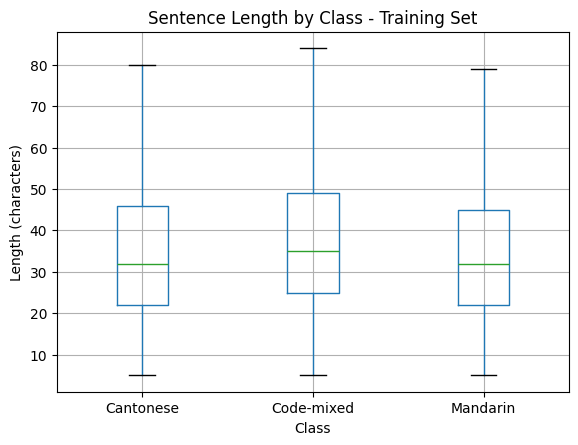

In [21]:
train.boxplot(column="text_length", by="label_name", showfliers=False)
plt.title("Sentence Length by Class - Training Set")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Length (characters)")
plt.show()


- Median sentence length in train: Cantonese 32, Mandarin 32, code-mixed 35 characters.
- Cantonese and Mandarin sentences have almost the same length distribution. Code-mixed sentences are slightly longer on average, but the three distributions overlap heavily, so sentence length alone is a weak signal for the class and is unlikely to act as a shortcut.
- Within the one group we inspected, all versions of the sentence had the same length, so corruption itself does not seem to change length. A possible explanation for the difference is that longer source sentences have more words that can be swapped and therefore produce more code-mixed versions. This is a hypothesis and was not tested.

- The maximum lengths show a few extreme outliers: while no Cantonese row is longer than 80 characters, one Mandarin row (716 characters) and three code-mixed rows (713–714 characters) are much longer. These 4 rows are the only ones above 100 characters; all four come from the same source (`source_id` 8038) and look like a whole paragraph rather than a sentence. They are hidden in the boxplot because it does not draw outliers (`showfliers=False`).

## Summary of findings

- **Sizes and format:** train 42,753, validation 2,425, test 2,341 rows; fields `id`, `source_id`, `sentence`, `label`. These match `DATA_CARD.md`.
- **Class balance:** label 2 (code-mixed) is about two thirds of every split; Cantonese and Mandarin are about one sixth each. The proportions are consistent across splits.
- **Structure:** each source sentence produced 1–8 rows. Versions of the same sentence are very similar at the character level (Cantonese vs. Mandarin similarity 0.88 in the inspected group), so the task depends on small character-level differences.
- **Conflicting labels:** 161 sentences in train (18 in validation, 12 in test) appear with two different labels. All conflicts involve label 2; no sentence is labelled both Cantonese and Mandarin.
- **Split overlap:** no `source_id` is shared between splits (group split). A few identical sentences still appear in more than one split (7 train/validation, 8 train/test) because the source corpus repeats some sentences under different `source_id`s.
- **Length:** Cantonese and Mandarin have similar lengths; code-mixed sentences are slightly longer, but the distributions overlap heavily.
- **Other quality notes:** some text contains likely conversion errors (e.g. `賣瞭`, `代錶隊`), some rows are sentence fragments, and 4 rows (about 714 characters) look like whole paragraphs.

## Open questions for the team

1. **2-class or 3-class task?** A 2-class version (labels 0 and 1) would be balanced and free of the label conflicts found above, but would drop two thirds of the data and the code-mixed class.
2. **How to handle conflicting and duplicated sentences?** Keep, drop, or report separately. Any cleaning is decided on the training and validation splits only, never by looking at test results.
3. **Verify against the upstream code:** the label definitions come from `canto-nlu/data/ld/README.md` and were not checked against the generation code; the same applies to the conversion-error and corruption hypotheses.
